[MovieLensデータセット](https://grouplens.org/datasets/movielens/)を用いて、SVDによる行列の低ランク近似の効用を試してみる。

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Load the data
# wget https://files.grouplens.org/datasets/movielens/ml-100k.zip
# unzip ml-100k.zip

In [2]:
# pandasのDataFrameにデータを読み込み、カラム名を設定
df = pd.read_csv('ml-100k/u.data', sep='\t', header=None)
df.columns = ['user_id', 'item_id', 'rating', 'timestamp']

In [3]:
# データの先頭5行を表示
df.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
unique_users = df['user_id'].nunique()
unique_items = df['item_id'].nunique()

print(f'Number of unique users: {unique_users}')
print(f'Number of unique items: {unique_items}')

Number of unique users: 943
Number of unique items: 1682


In [9]:
# 特定ユーザーのデータを抽出
df[df["user_id"] == 1].head()

,user_id,item_id,rating,timestamp
202,1,61,4,878542420
305,1,189,3,888732928
333,1,33,4,878542699
334,1,160,4,875072547
478,1,20,4,887431883


In [25]:
# user_id = 19のユーザーは何件のレビューを投稿しているか
df[df["user_id"] == 19]['item_id'].nunique()

20

In [91]:
# ピボットテーブルを作成
item_user_matrix = df.pivot(index='item_id', columns='user_id', values='rating')
# fill NaN values with 0
item_user_matrix = item_user_matrix.fillna(0)
# convert to numpy array
item_user_numpy_matrix = item_user_matrix.to_numpy()
#1682アイテムに対する評価を並べた列ベクトルが、943ユーザー分だけ並んだ行列
print(item_user_numpy_matrix.shape)

(1682, 943)


In [100]:
# 各ユーザー(columnに対応)の平均評価値を計算
# 0除算ワーニングを回避するため、0で割る場合は0を返すように設定
column_means = np.true_divide(item_user_numpy_matrix.sum(axis=0), (item_user_numpy_matrix != 0).sum(axis=0))

#ユーザーごとの平均値で0を置換,端数はきり捨て
for j in range(item_user_numpy_matrix.shape[1]):
    item_user_numpy_matrix[item_user_numpy_matrix[:, j] == 0, j] = np.round(column_means[j])


# まるめる
item_user_numpy_matrix = np.round(item_user_numpy_matrix)

# 中身を確認
print(item_user_numpy_matrix.shape)
print(item_user_numpy_matrix)
# 行列のランクも確認 (確認したけどuser数と同じなのでfull rankだった)
np.linalg.matrix_rank(item_user_numpy_matrix)

(1682, 943)
[[5. 4. 3. ... 5. 4. 3.]
 [3. 4. 3. ... 4. 4. 5.]
 [4. 4. 3. ... 4. 4. 3.]
 ...
 [4. 4. 3. ... 4. 4. 3.]
 [4. 4. 3. ... 4. 4. 3.]
 [4. 4. 3. ... 4. 4. 3.]]


943

行列 $A$を特異値分解する
$$
    A = U \Sigma V^T
$$
ただし$A$が(m,n)行列なら

- $U$は(m,r)行列,
- $\Sigma$は(r,r)行列,
- $V^T$は(r,n)行列

である。ただしrは行列Aのrank。

In [116]:
#行列を特異値分解してみる
U, s, Vt = np.linalg.svd(item_user_numpy_matrix, full_matrices=False)

In [117]:
#復元してみる
reconstructed_matrix = U @ np.diag(s) @ Vt
print('\nReconstructed matrix\n',reconstructed_matrix)


Reconstructed matrix
 [[5. 4. 3. ... 5. 4. 3.]
 [3. 4. 3. ... 4. 4. 5.]
 [4. 4. 3. ... 4. 4. 3.]
 ...
 [4. 4. 3. ... 4. 4. 3.]
 [4. 4. 3. ... 4. 4. 3.]
 [4. 4. 3. ... 4. 4. 3.]]


In [118]:
#特異値分解で得られた行列の形状
print('shape of U, s, Vt:', U.shape, s.shape, Vt.shape)

shape of U, s, Vt: (1682, 943) (943,) (943, 943)


このままでは(1682,943)行列を、(1682,943)行列 × (943,943)行列(これは対角行列だが) ×(943,943)行列の形にしているだけで、かえって事態を複雑にしているだけにしか見えないかもしれない。
しかし、ここでは真ん中の対角行列sの構造が重要になってくる。

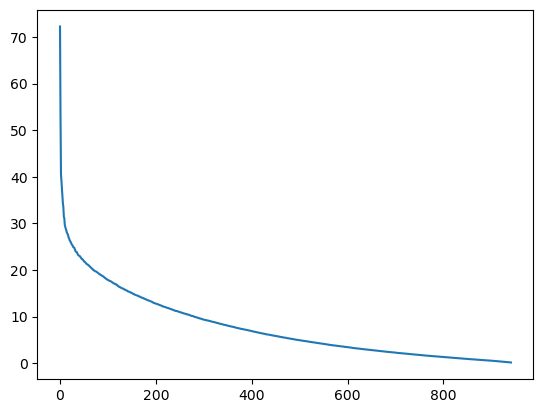

In [119]:
# 特異値ベクトルsをプロットしてみる
plt.plot(s[1:])

特異値は最初の50個くらいを取れば、あとは切り捨てても影響は少なそう。
実際にそうなのか、50番目より後の特異値&特異ベクトルを切り捨てた$U,\Sigma,V^T$を使って元の行列を復元することで確認してみる。

In [112]:
# U,Vについて最初の50 個の特異値を使って元の行列を近似してみる
k = 50
reconstructed_matrix = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
print(reconstructed_matrix)

[[5.76701559 3.9837986  3.04060839 ... 4.28476837 4.23282367 3.45541621]
 [3.54992879 3.96781614 2.96660899 ... 4.02815053 4.0495685  3.49114307]
 [4.40274941 4.01149671 3.10023882 ... 3.93026895 3.96378238 2.81960226]
 ...
 [3.99033426 3.9955923  2.99551925 ... 4.00571108 4.00604489 3.04461695]
 [4.00013224 3.99249474 2.99101396 ... 4.00466341 4.00481079 3.02550438]
 [4.00013224 3.99249474 2.99101396 ... 4.00466341 4.00481079 3.02550438]]


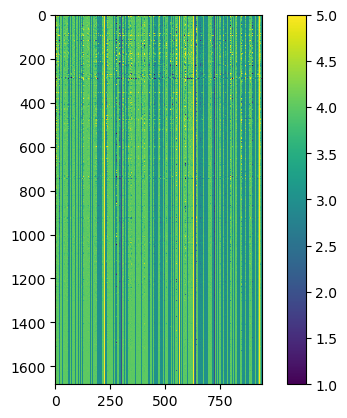

In [113]:
# reconstructed_matrixを画像として表示
# カラーバーも表示
plt.imshow(reconstructed_matrix,vmin=1,vmax=5, cmap='viridis',interpolation='nearest')
plt.colorbar()

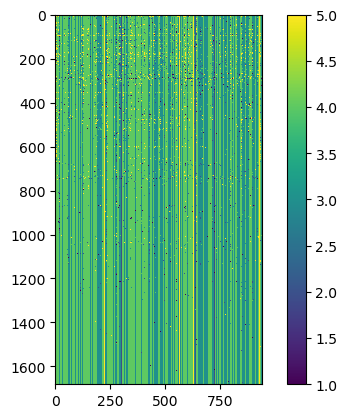

In [114]:
# 元のデータはこんな感じ
plt.imshow(item_user_numpy_matrix, vmin=1,vmax=5,cmap='viridis', interpolation='nearest')
plt.colorbar()

縦方向にスダレ状の構造が見えるのは、レビュー点数が入力されてない映画については各レビュワーが他の映画に与えたスコアの平均点で代用している(=全部同じスコアにしている)から。ここも$N(0,1)$くらいの正規分布ノイズをランダムに加えたらもうちょっとリアルなデータになりそう。
さすがにこれでは近似できてるか評価しにくいので、特定の1人について結果を見てみる。

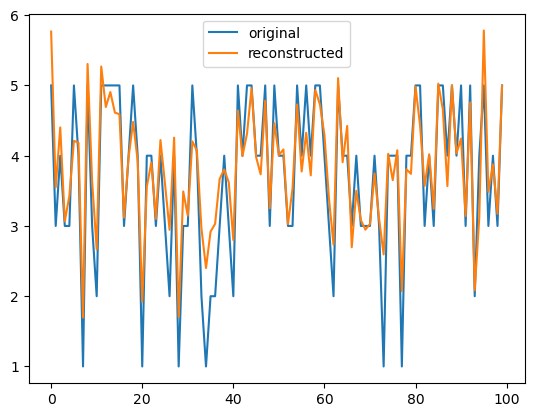

In [115]:
#user_id = 1の人について、最初の100アイテムの評価値を比べてみる。
plt.plot(item_user_numpy_matrix[:100,0], label='original')
plt.plot(reconstructed_matrix[:100,0], label='reconstructed')
plt.legend()

変換前: 

shape:(1682,943) 1682 * 943 = 1,586,126個のデータ

変換後:

- U.shape = (1682,50) 1682*50 = 84100
- s.shape = (50,50) 50*50 = 2500
- V.shape = (50,943) 50*943 = 47150

合計 133,750個のデータ